In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

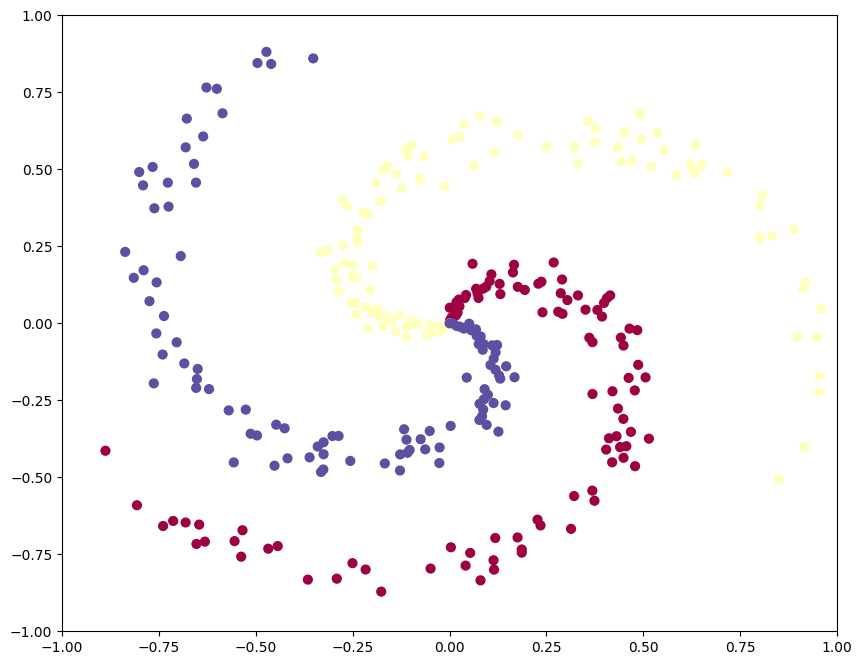

In [4]:
np.random.seed(0)
N=100
D=2
K=3
X=np.zeros((N*K,D))
y=np.zeros(N*K,dtype='uint8')

for j in range(K):
    ix=range(N*j,N*(j+1))
    r=np.linspace(0.0,1,N)
    t=np.linspace(j*4,(j+1)*4,N)+np.random.randn(N)*0.2
    #角度加随机噪音
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j
fig = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.show() 
#生成了螺旋状线性不可分的数据集

iteration 0:loss 1.099686
iteration 10:loss 1.099686
iteration 20:loss 1.099686
iteration 30:loss 1.099686
iteration 40:loss 1.099686
iteration 50:loss 1.099686
iteration 60:loss 1.099686
iteration 70:loss 1.099686
iteration 80:loss 1.099686
iteration 90:loss 1.099686
iteration 100:loss 1.099686
iteration 110:loss 1.099686
iteration 120:loss 1.099686
iteration 130:loss 1.099686
iteration 140:loss 1.099686
iteration 150:loss 1.099686
iteration 160:loss 1.099686
iteration 170:loss 1.099686
iteration 180:loss 1.099686
iteration 190:loss 1.099686
training accuracy:0.10


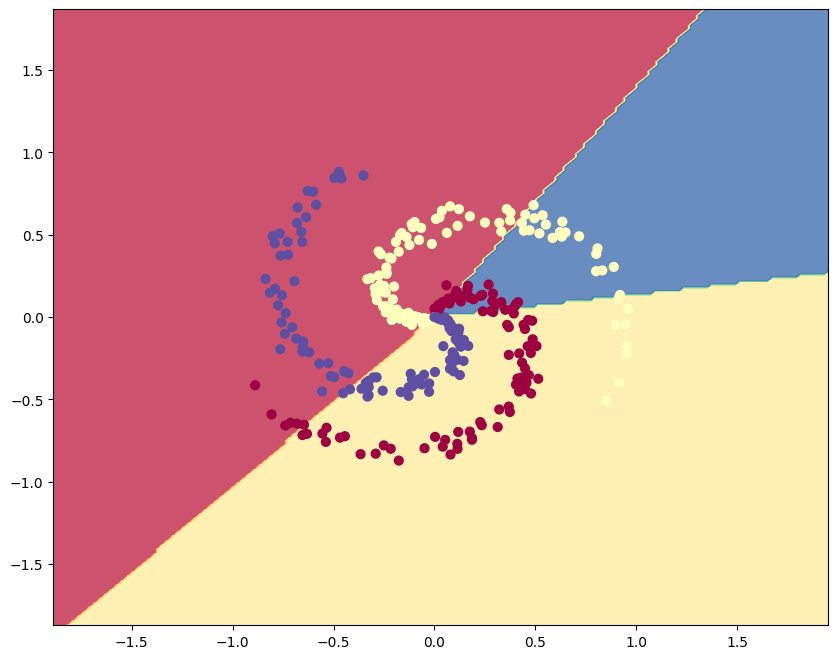

In [ ]:
#传统单层线性模型尝试对比
W=0.01*np.random.randn(D,K)
#生成标准正态分布随机数据，弱化权重，打破对称性
b=np.zeros((1,K))
#偏重归零，超参数设置
step_size=1e-0
reg=1e-3
num_examples=X.shape[0]
for i in range(200):
    scores=np.dot(X,W)+b
    #softmax消灭负数，放大差距
    exp_scores=np.exp(scores)
    probs=exp_scores/np.sum(exp_scores,axis=1,keepdims=True)
    #按行相加，保持维度，标准化概率
    #计算交叉熵损失
    corect_logprobs=-np.log(probs[range(num_examples),y])
    #取正确类别对应概率，衡量预测精准度
    data_loss=np.sum(corect_logprobs)/num_examples
    reg_loss=0.5*reg*np.sum(W*W)#L2正则化
    loss=data_loss+reg_loss
    if i%10==0:
        print("iteration %d:loss %f"%(i,loss))
    #反向传播算导数
    dscores=probs
    dscores[range(num_examples),y]-=1
    dscores/=num_examples
    dW=np.dot(X.T,dscores)
    db=np.sum(dscores,axis=0,keepdims=True)
    dW+=reg*W
scores=np.dot(X,W)+b
predicted_class=np.argmax(scores,axis=1)
print('training accuracy:%.2f'%(np.mean(predicted_class==y)))
#结果可视化
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

iteration 0: loss 1.098700
iteration 100: loss 0.724329
iteration 200: loss 0.730278
iteration 300: loss 0.677441
iteration 400: loss 0.441483
iteration 500: loss 0.393658
iteration 600: loss 0.362480
iteration 700: loss 0.351228
iteration 800: loss 0.338742
iteration 900: loss 0.323393
iteration 1000: loss 0.312706
iteration 1100: loss 0.303430
iteration 1200: loss 0.294410
iteration 1300: loss 0.285529
iteration 1400: loss 0.276626
iteration 1500: loss 0.269167
iteration 1600: loss 0.265338
iteration 1700: loss 0.263115
iteration 1800: loss 0.261339
iteration 1900: loss 0.259857
iteration 2000: loss 0.258430
iteration 2100: loss 0.257096
iteration 2200: loss 0.255808
iteration 2300: loss 0.254658
iteration 2400: loss 0.253629
iteration 2500: loss 0.252733
iteration 2600: loss 0.251925
iteration 2700: loss 0.251138
iteration 2800: loss 0.250408
iteration 2900: loss 0.249678
iteration 3000: loss 0.249148
iteration 3100: loss 0.248702
iteration 3200: loss 0.248231
iteration 3300: loss 0

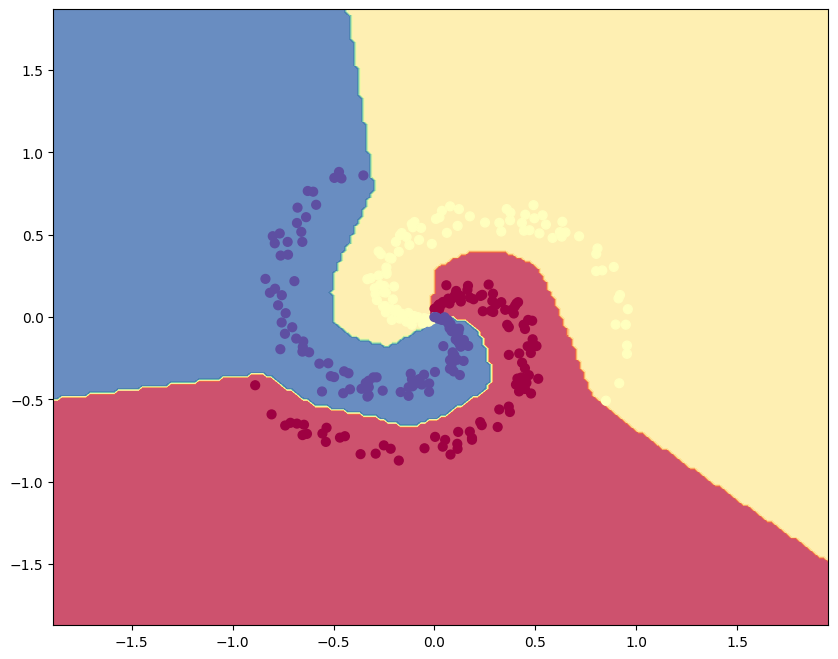

In [9]:
h=100
W=0.01*np.random.randn(D,h)
b=np.zeros((1,h))
W2=0.01*np.random.randn(h,K)
b2=np.zeros((1,K))
step_size=1e-0
reg=1e-3
num_examples=X.shape[0]
for i in range(10000):
    hidden_layer=np.maximum(0,np.dot(X,W)+b)
    scores=np.dot(hidden_layer,W2)+b2
    exp_scores=np.exp(scores)
    probs=exp_scores/np.sum(exp_scores,axis=1,keepdims=True)
    corect_logprobs=-np.log(probs[range(num_examples),y])
    data_loss=np.sum(corect_logprobs)/num_examples
    reg_loss=0.5*reg*np.sum(W*W)+0.5*reg*np.sum(W2*W2)
    loss=data_loss+reg_loss
    if i%100==0:
        print("iteration %d: loss %f"%(i,loss))
    
    dscores=probs
    dscores[range(num_examples),y]-=1
    dscores/=num_examples
    dW2=np.dot(hidden_layer.T ,dscores)
    db2=np.sum(dscores,axis=0,keepdims=True)
    dhidden=np.dot(dscores,W2.T)
    dhidden[hidden_layer<=0]=0
    dW=np.dot(X.T,dhidden)
    db=np.sum(dhidden,axis=0,keepdims=True)
    dW2+=reg*W2
    dW+=reg*W 
    W += -step_size * dW
    b += -step_size * db
    W2 += -step_size * dW2
    b2 += -step_size * db2

# 算准确率
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print('training accuracy: %.2f' % (np.mean(predicted_class == y)))

# 把分割线画出来
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = np.dot(np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b), W2) + b2
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()